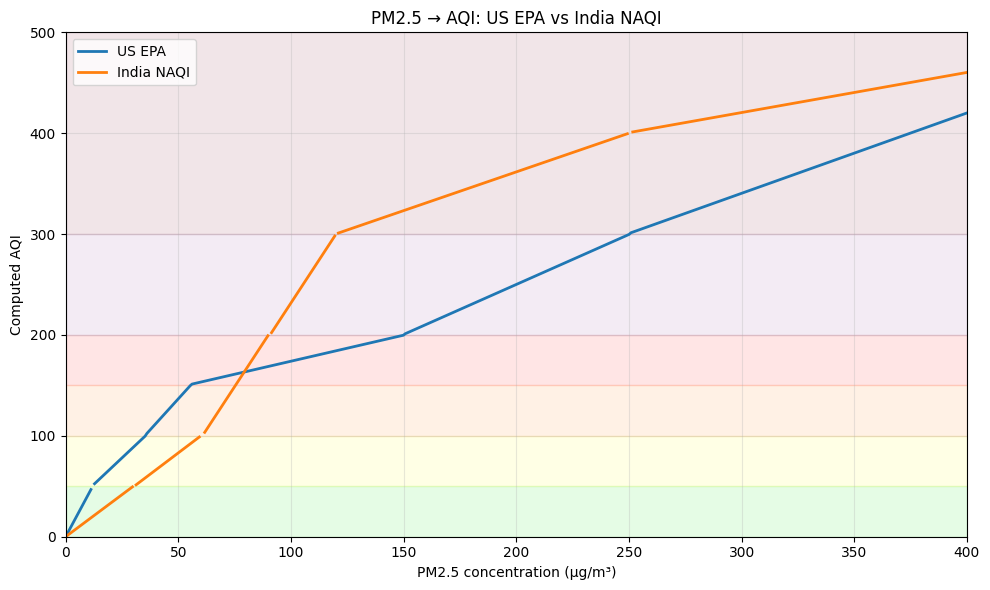

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Piecewise-linear AQI: given concentration and a list of (C_lo, C_hi, I_lo, I_hi)
def compute_subindex(c, breakpoints):
    for c_lo, c_hi, i_lo, i_hi in breakpoints:
        if c_lo <= c <= c_hi:
            return ((i_hi - i_lo) / (c_hi - c_lo)) * (c - c_lo) + i_lo
    return None  # out of defined range

# US EPA PM2.5 (24-hour avg) — pre-2024 revision, still widely used
epa_pm25 = [
    (0.0,   12.0,   0,   50),
    (12.1,  35.4,   51,  100),
    (35.5,  55.4,   101, 150),
    (55.5,  150.4,  151, 200),
    (150.5, 250.4,  201, 300),
    (250.5, 500.4,  301, 500),
]

# India CPCB NAQI PM2.5 (24-hour avg)
naqi_pm25 = [
    (0,   30,   0,   50),
    (31,  60,   51,  100),
    (61,  90,   101, 200),
    (91,  120,  201, 300),
    (121, 250,  301, 400),
    (251, 500,  401, 500),
]

# Sweep concentrations and compute both AQI curves
concentrations = np.linspace(0, 400, 500)
epa_aqi  = [compute_subindex(c, epa_pm25)  for c in concentrations]
naqi_aqi = [compute_subindex(c, naqi_pm25) for c in concentrations]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(concentrations, epa_aqi,  label="US EPA",   linewidth=2)
ax.plot(concentrations, naqi_aqi, label="India NAQI", linewidth=2)

# Shade the six EPA category bands on the AQI axis for reference
band_colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"]
band_edges  = [0, 50, 100, 150, 200, 300, 500]
for lo, hi, color in zip(band_edges[:-1], band_edges[1:], band_colors):
    ax.axhspan(lo, hi, alpha=0.10, color=color)

ax.set_xlabel("PM2.5 concentration (µg/m³)")
ax.set_ylabel("Computed AQI")
ax.set_title("PM2.5 → AQI: US EPA vs India NAQI")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 400)
ax.set_ylim(0, 500)
plt.tight_layout()
plt.show()